In [1]:
%cd ..

c:\Users\almei\Documents\GitHub\research_ner_leaderboard


In [2]:
import torch
import numpy as np
from transformers import AutoTokenizer
from transformers import AutoModelForTokenClassification, Trainer, TrainingArguments

from spesia_ner.metrics import compute_metrics
from spesia_ner.datasets import ClinicalRecordsDataset, DataCollatorForMultiLabelTokenClassification
from spesia_ner.trainers import MultiLabelTokenTrainer

model_id = "jhu-clsp/mmBERT-base"
tags_to_consider = [
    # 'Abbreviation',
    # 'Negation',
    # 'Therapeutic or Preventive Procedure',
    # 'Health Care Activity',
    # 'Diagnostic Procedure',
    # 'Clinical Attribute',
    # 'Laboratory or Test Result',
    # 'Health Care Related Organization',
    # 'Professional or Occupational Group',
    # 'Patient or Disabled Group',
    # 'Sign or Symptom',
    # 'Injury or Poisoning',
    # 'Finding',
    # 'Disease or Syndrome',
    # 'Medical Device',
    # 'Drug Delivery Device',
    # 'Temporal Concept',
    # 'Pharmacologic Substance',
    # 'Organic Chemical',
    # 'Body Part, Organ, or Organ Component',
    # 'Body Location or Region',
    ]

semantic_groups_to_consider = [
    # 'Activities & Behaviors',
    'Anatomy',
    'Chemicals & Drugs',
    'Concepts & Ideas',
    'Devices',
    'Disorders',
    # 'Genes & Molecular Sequences',
    # 'Geographic Areas',
    'Living Beings',
    # 'Objects',
    # 'Occupations',
    'Organizations',
    'Phenomena',
    'Physiology',
    'Procedures'
]

tokenizer = AutoTokenizer.from_pretrained(model_id, use_fast=True)

train_dataset = ClinicalRecordsDataset(
    'data/SemClinBr/annotated_records', 
    tokenizer, 
    semantic_groups_to_consider=semantic_groups_to_consider,
    label_type='semantic_groups', 
    annotation_scheme='BIO',
    split="train")

val_dataset = ClinicalRecordsDataset(
    'data/SemClinBr/annotated_records', 
    tokenizer, 
    semantic_groups_to_consider=semantic_groups_to_consider,
    label_type='semantic_groups', 
    annotation_scheme='BIO',
    split="val")

test_dataset = ClinicalRecordsDataset(
    'data/SemClinBr/annotated_records', 
    tokenizer, 
    semantic_groups_to_consider=semantic_groups_to_consider,
    label_type='semantic_groups', 
    annotation_scheme='BIO',
    split="test")

model = AutoModelForTokenClassification.from_pretrained(model_id, num_labels=train_dataset.num_labels)

Mapping tags to UMLS semantic groups: 100%|██████████| 1000/1000 [00:00<00:00, 65465.42it/s]


Ignored labels during data split due to low sample count: ['Genes & Molecular Sequences', 'Geographic Areas', 'Occupations']


Mapping tags to UMLS semantic groups: 100%|██████████| 1000/1000 [00:00<00:00, 49794.07it/s]


Ignored labels during data split due to low sample count: ['Genes & Molecular Sequences', 'Geographic Areas', 'Occupations']


Mapping tags to UMLS semantic groups: 100%|██████████| 1000/1000 [00:00<00:00, 53724.23it/s]


Ignored labels during data split due to low sample count: ['Genes & Molecular Sequences', 'Geographic Areas', 'Occupations']


Some weights of ModernBertForTokenClassification were not initialized from the model checkpoint at jhu-clsp/mmBERT-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Exception ignored in: <function tqdm.__del__ at 0x0000023B78AA40E0>
Traceback (most recent call last):
  File "c:\Users\almei\Documents\GitHub\research_ner_leaderboard\.venv\Lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "c:\Users\almei\Documents\GitHub\research_ner_leaderboard\.venv\Lib\site-packages\tqdm\notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm' object has no attribute 'disp'


In [ ]:
from spesia_ner.trainers import EarlyStoppingCallback


training_args = TrainingArguments(
    output_dir="./output",
    per_device_train_batch_size=10,
    gradient_accumulation_steps=5,
    num_train_epochs=40,
    learning_rate=5e-5,
    include_for_metrics=['inputs'],
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
)

data_collator = DataCollatorForMultiLabelTokenClassification(
    pad_token_id=tokenizer.pad_token_id,
    max_length=512,
    num_labels=train_dataset.num_labels
)

trainer = MultiLabelTokenTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(patience=5)],
    pos_weight=train_dataset.pos_weight
)

trainer.train()

Epoch,Training Loss,Validation Loss,Best Threshold,Macro Precision,Macro Recall,Macro F1,Macro Auc,Micro Precision,Micro Recall,Micro F1,Micro Auc
1,4.849100,2.010062,0.100000,0.069075,0.161332,0.070826,0.632644,0.112487,0.608580,0.189877,0.881087
2,2.009500,1.680747,0.180000,0.171781,0.204014,0.147730,0.784170,0.209102,0.609342,0.311358,0.924245
3,1.690900,1.395520,0.290000,0.255820,0.269043,0.249127,0.865607,0.515011,0.607143,0.557295,0.954937
4,1.462600,1.233175,0.330000,0.404141,0.331713,0.310892,0.909487,0.590963,0.662268,0.624587,0.966791
5,1.275800,1.130178,0.320000,0.429240,0.366214,0.361383,0.926380,0.653290,0.682119,0.667393,0.972408
6,1.117600,1.070146,0.300000,0.417483,0.401402,0.384463,0.934615,0.650143,0.731850,0.688581,0.975725
7,0.980800,1.036068,0.320000,0.428471,0.403195,0.399492,0.939288,0.667806,0.739297,0.701735,0.976893
8,0.868000,1.042708,0.170000,0.394522,0.464403,0.408504,0.942965,0.566510,0.804334,0.664792,0.975711
9,0.780400,1.078461,0.380000,0.452238,0.409424,0.405049,0.944775,0.687982,0.730325,0.708521,0.975745
10,0.700100,1.134443,0.240000,0.419739,0.450895,0.411282,0.944807,0.594080,0.797472,0.680912,0.975635


TrainOutput(global_step=156, training_loss=1.3395021634224133, metrics={'train_runtime': 287.2882, 'train_samples_per_second': 83.122, 'train_steps_per_second': 1.671, 'total_flos': 2644951661015040.0, 'train_loss': 1.3395021634224133, 'epoch': 13.0})

In [4]:
trainer.eval_dataset = test_dataset
trainer.evaluate()

{'eval_loss': 0.884868323802948,
 'eval_best_threshold': 0.38,
 'eval_macro_precision': 0.43480926977919065,
 'eval_macro_recall': 0.4280897034231673,
 'eval_macro_f1': 0.4280873170671867,
 'eval_macro_auc': 0.9179372483796083,
 'eval_micro_precision': 0.7471848393298545,
 'eval_micro_recall': 0.7763319350512228,
 'eval_micro_f1': 0.7614795739856969,
 'eval_micro_auc': 0.9831481193968719,
 'eval_runtime': 8.6935,
 'eval_samples_per_second': 23.466,
 'eval_steps_per_second': 2.991,
 'epoch': 13.0}

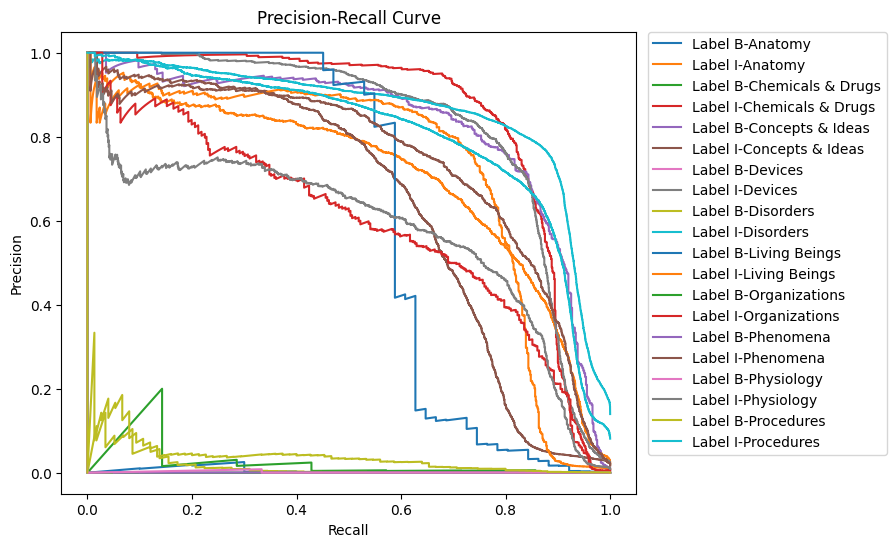

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# Get predictions object
pred_output = trainer.predict(test_dataset)

# Get probabilities (sigmoid for multilabel)
probs = 1 / (1 + np.exp(-pred_output.predictions))
labels = pred_output.label_ids.astype(int)

# For single-label: flatten arrays
if probs.shape[-1] == 1:
    probs_flat = probs.reshape(-1)
    labels_flat = labels.reshape(-1)
else:
    # For multilabel: plot for each label
    probs_flat = probs.reshape(-1, probs.shape[-1])
    labels_flat = labels.reshape(-1, labels.shape[-1])

plt.figure(figsize=(10,6))
# Plot for each label (or just one if single-label)
for i in range(probs_flat.shape[-1] if probs_flat.ndim > 1 else 1):
    if probs_flat.ndim > 1:
        y_score = probs_flat[:, i]
        y_true = labels_flat[:, i]
        label_name = f"Label {test_dataset.idx_to_label[i]}"
    else:
        y_score = probs_flat
        y_true = labels_flat
        label_name = "Label"

    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    plt.plot(recall, precision, label=label_name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.subplots_adjust(right=0.7)  # make room on the right for the legend
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.show()

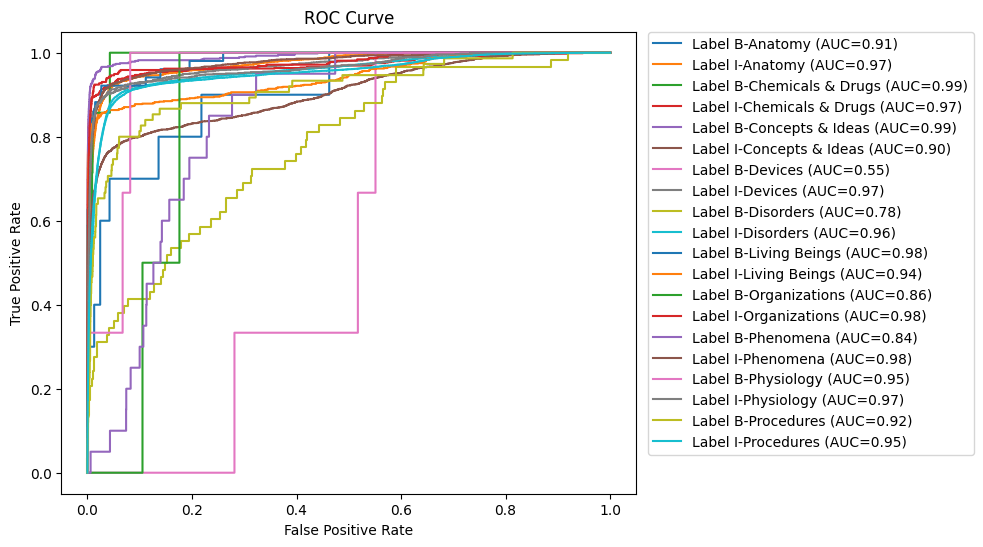

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Get predictions object
pred_output = trainer.predict(test_dataset)

# Get probabilities (sigmoid for multilabel)
probs = 1 / (1 + np.exp(-pred_output.predictions))
labels = pred_output.label_ids.astype(int)

# For single-label: flatten arrays
if probs.shape[-1] == 1:
    probs_flat = probs.reshape(-1)
    labels_flat = labels.reshape(-1)
else:
    # For multilabel: plot for each label
    probs_flat = probs.reshape(-1, probs.shape[-1])
    labels_flat = labels.reshape(-1, labels.shape[-1])

plt.figure(figsize=(10,6))
# Plot ROC curve for each label (or just one if single-label)
for i in range(probs_flat.shape[-1] if probs_flat.ndim > 1 else 1):
    if probs_flat.ndim > 1:
        y_score = probs_flat[:, i]
        y_true = labels_flat[:, i]
        label_name = f"Label {test_dataset.idx_to_label[i]}"
    else:
        y_score = probs_flat
        y_true = labels_flat
        label_name = "Label"

    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)
    plt.plot(fpr, tpr, label=f"{label_name} (AUC={auc:.2f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.subplots_adjust(right=0.7)  # make room on the right for the legend
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.show()